In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv(filepath_or_buffer="players.csv")

In [24]:
df.head()

,player_id,common_name,first_name,last_name,overall_rating,position,alternate_positions,club,league,nationality,...,defending_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,edition,snapshot_date
0,227203,Alexia Putellas,Alexia,Putellas Segura,91,CM,CAM ST,London City,Barclays WSL,Spain,...,60,82,64,15,17,11,15,10,fc27,2026-09-12
1,231747,NaN,Kylian,Mbappé,91,ST,LW,Real Madrid,LALIGA EA SPORTS,France,...,15,34,24,13,5,7,11,6,fc27,2026-09-12
2,239085,NaN,Erling,Haaland,91,ST,NaN,Manchester City,Premier League,Norway,...,42,47,33,7,14,13,11,7,fc27,2026-09-12
3,192119,NaN,Thibaut,Courtois,90,GK,NaN,Real Madrid,LALIGA EA SPORTS,Belgium,...,20,18,16,87,89,78,90,90,fc27,2026-09-12
4,202126,NaN,Harry,Kane,90,ST,NaN,FC Bayern München,Bundesliga,England,...,46,44,42,8,10,11,14,11,fc27,2026-09-12


### 0. Basic Cleaning and Removal of Unnecessary Columns

In [25]:
cols_to_drop = [
    "common_name",
    "height_cm",
    "weight_kg",
    "alternate_positions",
]

df = df.drop(columns=cols_to_drop)

In [26]:
df.head()

,player_id,first_name,last_name,overall_rating,position,club,league,nationality,gender,preferred_foot,...,defending_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,edition,snapshot_date
0,227203,Alexia,Putellas Segura,91,CM,London City,Barclays WSL,Spain,Women's Football,Left,...,60,82,64,15,17,11,15,10,fc27,2026-09-12
1,231747,Kylian,Mbappé,91,ST,Real Madrid,LALIGA EA SPORTS,France,Men's Football,Right,...,15,34,24,13,5,7,11,6,fc27,2026-09-12
2,239085,Erling,Haaland,91,ST,Manchester City,Premier League,Norway,Men's Football,Left,...,42,47,33,7,14,13,11,7,fc27,2026-09-12
3,192119,Thibaut,Courtois,90,GK,Real Madrid,LALIGA EA SPORTS,Belgium,Men's Football,Left,...,20,18,16,87,89,78,90,90,fc27,2026-09-12
4,202126,Harry,Kane,90,ST,FC Bayern München,Bundesliga,England,Men's Football,Right,...,46,44,42,8,10,11,14,11,fc27,2026-09-12


### 1. Goalkeepers vs. Outfiled Players

In [27]:
cols_for_summary = [
    "first_name",
    "last_name",
    "overall_rating",
    "pace",
    "shooting",
    "passing",
    "dribbling",
    "defending",
    "physicality",
]

goal_keepers = df[df["position"] == "GK"][cols_for_summary]
outfield_players = df[df["position"] != "GK"][cols_for_summary]

In [28]:
goal_keepers.head()

,first_name,last_name,overall_rating,pace,shooting,passing,dribbling,defending,physicality
3,Thibaut,Courtois,90,87,89,78,90,46,90
17,Gianluigi,Donnarumma,89,90,83,72,90,46,88
27,Jan,Oblak,88,85,90,79,87,46,86
30,David,Raya Martín,88,87,86,88,88,58,86
47,Alisson,Ramses Becker,87,85,87,82,86,50,86


In [29]:
outfield_players.head()

,first_name,last_name,overall_rating,pace,shooting,passing,dribbling,defending,physicality
0,Alexia,Putellas Segura,91,80,90,91,92,72,75
1,Kylian,Mbappé,91,96,91,80,92,29,76
2,Erling,Haaland,91,87,92,71,80,47,89
4,Harry,Kane,90,62,94,83,82,49,83
5,Ousmane,Dembélé,90,90,89,83,93,55,70


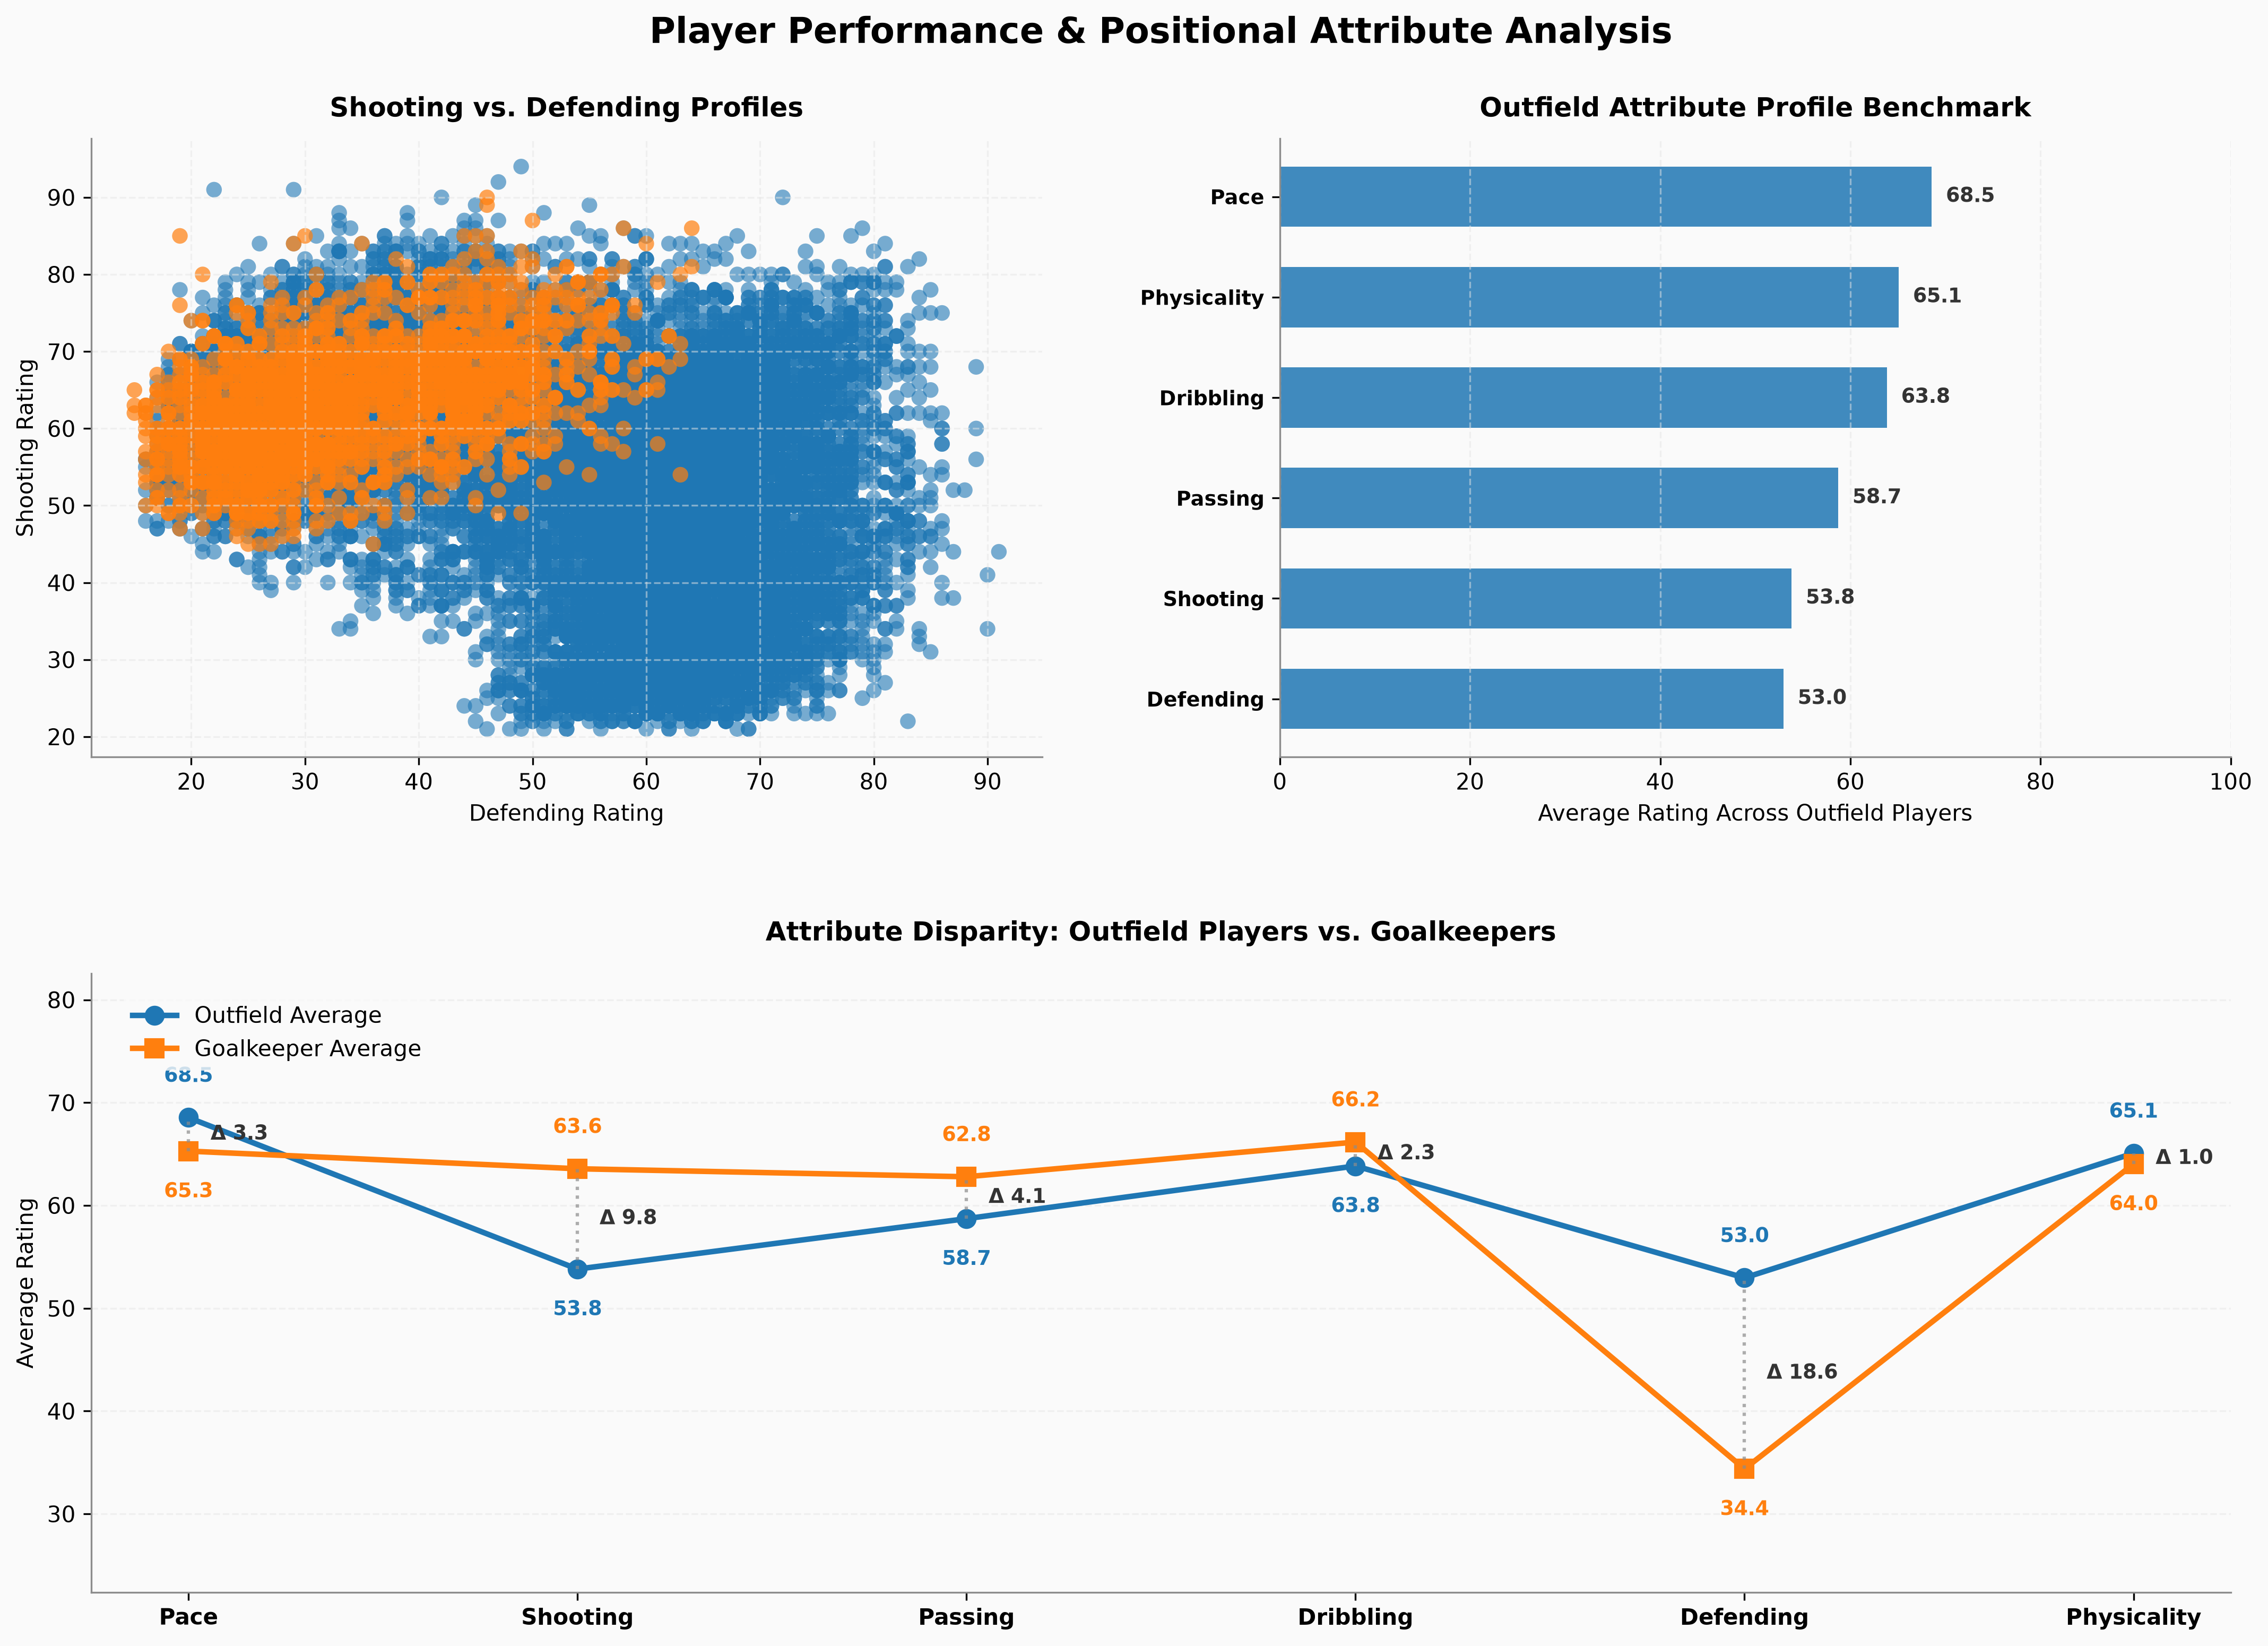

In [37]:
fig = plt.figure(figsize=(16, 11), dpi=300)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.35, wspace=0.25)

ax_top_left = fig.add_subplot(gs[0, 0])
ax_top_right = fig.add_subplot(gs[0, 1])
ax_bottom = fig.add_subplot(gs[1, :])

COLOR_OUTFIELD = "#1F77B4"
COLOR_GK = "#FF7F0E"
COLOR_MUTED = "#8C8C8C"
COLOR_BG = "#FAFAFA"
COLOR_GRID = "#E5E5E5"

fig.patch.set_facecolor(COLOR_BG)
for ax in [ax_top_left, ax_top_right, ax_bottom]:
    ax.set_facecolor(COLOR_BG)

metrics = ["pace", "shooting", "passing", "dribbling", "defending", "physicality"]

gk_subset = df[df["position"] == "GK"]
outfield_subset = df[df["position"] != "GK"]

ax_top_left.scatter(
    outfield_subset["defending"],
    outfield_subset["shooting"],
    c=COLOR_OUTFIELD,
    alpha=0.6,
    s=50,
    edgecolors="none",
    label="Outfield Players",
)
ax_top_left.scatter(
    gk_subset["defending"],
    gk_subset["shooting"],
    c=COLOR_GK,
    alpha=0.7,
    s=50,
    edgecolors="none",
    label="Goalkeepers",
)

ax_top_left.set_title(
    "Shooting vs. Defending Profiles", fontsize=12, fontweight="bold", pad=10
)
ax_top_left.set_xlabel("Defending Rating", fontsize=10)
ax_top_left.set_ylabel("Shooting Rating", fontsize=10)
ax_top_left.grid(True, linestyle="--", alpha=0.5, color=COLOR_GRID)
ax_top_left.spines["top"].set_visible(False)
ax_top_left.spines["right"].set_visible(False)
ax_top_left.spines["left"].set_color(COLOR_MUTED)
ax_top_left.spines["bottom"].set_color(COLOR_MUTED)

attribute_means = outfield_subset[metrics].mean().sort_values(ascending=True)
y_pos = range(len(attribute_means))

ax_top_right.barh(
    y_pos,
    attribute_means.values,
    color=COLOR_OUTFIELD,
    alpha=0.85,
    height=0.6,
)
ax_top_right.set_yticks(y_pos)
labels = [m.capitalize() for m in attribute_means.index]
ax_top_right.set_yticklabels(labels, fontsize=9, fontweight="bold")
ax_top_right.set_xlabel("Average Rating Across Outfield Players", fontsize=10)
ax_top_right.set_title(
    "Outfield Attribute Profile Benchmark", fontsize=12, fontweight="bold", pad=10
)
ax_top_right.set_xlim(0, 100)
ax_top_right.grid(True, axis="x", linestyle="--", alpha=0.5, color=COLOR_GRID)
ax_top_right.spines["top"].set_visible(False)
ax_top_right.spines["right"].set_visible(False)
ax_top_right.spines["left"].set_color(COLOR_MUTED)
ax_top_right.spines["bottom"].set_color(COLOR_MUTED)

for i, val in enumerate(attribute_means.values):
    ax_top_right.text(
        val + 1.5,
        i,
        f"{val:.1f}",
        va="center",
        color="#333333",
        fontweight="bold",
        fontsize=9,
    )

mean_outfield = outfield_subset[metrics].mean()
mean_gk = gk_subset[metrics].mean()

x_indices = np.arange(len(metrics))

ax_bottom.plot(
    x_indices,
    mean_outfield.values,
    color=COLOR_OUTFIELD,
    marker="o",
    linewidth=2.5,
    markersize=8,
    label="Outfield Average",
)
ax_bottom.plot(
    x_indices,
    mean_gk.values,
    color=COLOR_GK,
    marker="s",
    linewidth=2.5,
    markersize=8,
    label="Goalkeeper Average",
)

all_vals = np.concatenate([mean_outfield.values, mean_gk.values])
y_min_val, y_max_val = np.min(all_vals), np.max(all_vals)
ax_bottom.set_ylim(y_min_val - 12, y_max_val + 14)

for idx, (m_val, g_val) in enumerate(zip(mean_outfield.values, mean_gk.values)):
    ax_bottom.vlines(
        x=idx,
        ymin=min(m_val, g_val),
        ymax=max(m_val, g_val),
        color=COLOR_MUTED,
        linestyle=":",
        alpha=0.7,
        linewidth=1.5,
    )
    diff = abs(m_val - g_val)
    mid_y = (m_val + g_val) / 2
    ax_bottom.annotate(
        f"Δ {diff:.1f}",
        xy=(idx, mid_y),
        xytext=(10, 0),
        textcoords="offset points",
        fontsize=9,
        color="#333333",
        va="center",
        fontweight="semibold",
    )

    top_val, top_color = (m_val, COLOR_OUTFIELD) if m_val >= g_val else (g_val, COLOR_GK)
    bot_val, bot_color = (g_val, COLOR_GK) if m_val >= g_val else (m_val, COLOR_OUTFIELD)

    ax_bottom.text(
        idx,
        top_val + 3.0,
        f"{top_val:.1f}",
        ha="center",
        va="bottom",
        color=top_color,
        fontweight="bold",
        fontsize=9,
    )
    ax_bottom.text(
        idx,
        bot_val - 3.0,
        f"{bot_val:.1f}",
        ha="center",
        va="top",
        color=bot_color,
        fontweight="bold",
        fontsize=9,
    )

ax_bottom.set_xticks(x_indices)
ax_bottom.set_xticklabels(
    [m.capitalize() for m in metrics], fontsize=10, fontweight="bold"
)
ax_bottom.set_ylabel("Average Rating", fontsize=10)
ax_bottom.set_title(
    "Attribute Disparity: Outfield Players vs. Goalkeepers",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
ax_bottom.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),
    frameon=True,
    facecolor=COLOR_BG,
    edgecolor="none",
    fontsize=10,
)
ax_bottom.grid(True, axis="y", linestyle="--", alpha=0.5, color=COLOR_GRID)
ax_bottom.spines["top"].set_visible(False)
ax_bottom.spines["right"].set_visible(False)
ax_bottom.spines["left"].set_color(COLOR_MUTED)
ax_bottom.spines["bottom"].set_color(COLOR_MUTED)

fig.suptitle(
    "Player Performance & Positional Attribute Analysis",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

fig.subplots_adjust(top=0.91, bottom=0.08, left=0.08, right=0.92)